# 05 — Reinforcement Learning Trading Agent (AAPL)

This notebook implements two RL agents:
- **DQN**: Dueling Deep Q-Network with Prioritized Experience Replay
- **PPO**: Proximal Policy Optimization (Actor-Critic)

Both agents use predictions from the trained LSTM/GRU models (regime-specific) as part of their state representation and make **Buy / Hold / Sell** decisions for AAPL.

---
**Pipeline**:
1. Load AAPL feature data + trained models
2. Reconstruct model classes and load weights
3. Pre-compute LSTM predictions for all timesteps
4. Build a custom OpenAI-Gym style trading environment
5. Train DQN agent (300 episodes)
6. Train PPO agent (200 epochs)
7. Evaluate both on the held-out test set
8. Save results to `reports/rl_results.pkl`

---
## 🎓 Assignment Instructions

This notebook has **7 TODOs** for you to complete, marked with `# TODO N (DIFFICULTY):`
comments and `raise NotImplementedError(...)`. Everything else (data loading,
feature engineering, model loading, training loops, plotting) is already
implemented — you only need to fill in the specific lines described in the
markdown cell directly above each TODO.

**Difficulty breakdown:** 4 × EASY, 2 × MEDIUM, 1 × HARD.

| # | Difficulty | Location | What you're implementing |
|---|---|---|---|
| 1 | EASY | `StockTradingEnv.get_action_mask()` | Which actions are currently legal |
| 2 | EASY | `StockTradingEnv.step()` | Exponential drawdown penalty |
| 3 | EASY | `StockTradingEnv.step()` | Overtrading penalty |
| 4 | MEDIUM | `DuelingDQN.forward()` | Dueling V/A → Q combination |
| 5 | EASY | `DQNAgent.decay_epsilon()` | Epsilon-greedy decay |
| 6 | MEDIUM | `DQNAgent.update()` | Double DQN target computation |
| 7 | HARD | `PPOAgent.compute_gae()` | GAE backward recursion |

**How to know you're done:** a cell with an unfinished TODO will raise
`NotImplementedError` when run. Once every TODO is filled in, all cells
should run top-to-bottom without errors, and training/evaluation should
produce sensible (not necessarily great) results.

**Tip:** don't skip the markdown cell right above a TODO — it has the exact
formula/logic you need, so you shouldn't need to derive anything from
scratch.
---

In [1]:
# ─── IMPORTS ─────────────────────────────────────────────────────────────────
import os, random, pickle, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque, namedtuple
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.notebook import tqdm
import seaborn as sns

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


In [2]:
# ─── CONSTANTS ────────────────────────────────────────────────────────────────
SYMBOL           = 'AAPL'
SEQUENCE_LEN     = 60          # lookback window (same as training)
INITIAL_CAPITAL  = 100_000.0   # USD
TRANSACTION_COST = 0.001       # 0.1% per trade (slippage + commission)
MAX_POSITION     = 1.0         # max fraction of capital in stock

# ── Reward-Shaping Hyperparameters (Sortino / Drawdown / Overtrading) ────────
SORTINO_DOWNSIDE_COEF = 25.0     # weight on squared negative-return penalty
SORTINO_TARGET_RETURN = 0.0      # MAR (minimum acceptable per-step return)
TXN_PENALTY_COEF      = 0.0015   # extra reward penalty per executed trade (flip)
DD_THRESHOLD          = 0.05     # drawdown tolerance before penalty kicks in (5%)
DD_PENALTY_COEF       = 0.02     # scale of exponential drawdown penalty
DD_PENALTY_K          = 15.0     # steepness of exponential drawdown penalty
MIN_HOLD_STEPS        = 3        # minimum bars a position should be held
FLIP_PENALTY_COEF     = 0.0008   # penalty per bar short of MIN_HOLD_STEPS on a flip
PATIENCE_BONUS_COEF   = 0.00005  # small per-bar bonus for holding steady
PATIENCE_BONUS_CAP    = 0.0005   # cap on the patience bonus

# ── Feature-Engineering / State Hyperparameters ──────────────────────────────
FRAME_STACK_K = 3        # number of trailing bars stacked into the state (temporal context)
GK_VOL_WINDOW = 14       # Garman-Klass rolling window
ADX_WINDOW    = 14       # Wilder's ADX window
EMA_SLOW      = 50       # slow EMA for trend-distance feature

# ── LR Scheduler Hyperparameters (Cosine Annealing with Warm Restarts) ───────
DQN_SCHED_T0   = 50        # episodes until first restart
DQN_MIN_LR     = 1e-6
PPO_SCHED_T0   = 20        # epochs until first restart
PPO_MIN_LR     = 1e-6

# ── Recurrent-PPO Hyperparameter ─────────────────────────────────────────────
PPO_CHUNK_LEN  = 64        # truncated-BPTT sequence length (PPO_ROLLOUT_STEPS should be a multiple of this)
TRAIN_RATIO      = 0.70
VAL_RATIO        = 0.15
# TEST_RATIO = 0.15 (implied)

# ── DQN Hyperparameters ──────────────────────────────────────────────────────
DQN_EPISODES      = 30
DQN_BATCH_SIZE    = 64
DQN_GAMMA         = 0.99
DQN_LR            = 1e-4
DQN_EPS_START     = 1.0
DQN_EPS_END       = 0.01
DQN_EPS_DECAY     = 0.995
DQN_TARGET_UPDATE = 10         # sync target network every N episodes
DQN_MEMORY_SIZE   = 50_000
DQN_HIDDEN_DIM    = 256

# ── PPO Hyperparameters ──────────────────────────────────────────────────────
PPO_EPOCHS        = 20       # number of training iterations
PPO_ROLLOUT_STEPS = 2048       # steps per rollout collection
PPO_MINI_BATCH    = 64
PPO_LR            = 3e-4
PPO_GAMMA         = 0.99
PPO_GAE_LAMBDA    = 0.95
PPO_CLIP_EPS      = 0.2
PPO_ENTROPY_COEF  = 0.01
PPO_VF_COEF       = 0.5
PPO_MAX_GRAD_NORM = 0.5
PPO_UPDATE_EPOCHS = 10         # inner epochs per rollout
PPO_HIDDEN_DIM    = 256

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath('.')
DATA_DIR    = os.path.join(BASE_DIR, 'data', 'processed')
MODEL_DIR   = os.path.join(BASE_DIR, 'models')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')

print('Constants set.')
print(f'  Train/Val/Test split: {int(TRAIN_RATIO*100)}/{int(VAL_RATIO*100)}/15%')

Constants set.
  Train/Val/Test split: 70/15/15%


## 1  Load Data

In [3]:
# ─── LOAD AAPL FEATURES ───────────────────────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, f'{SYMBOL}_features.csv'), parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Dataset: {df.shape[0]} rows x {df.shape[1]} cols')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Columns: {list(df.columns)}')

Dataset: 8538 rows x 39 cols
Date range: 1981-02-24 to 2014-12-29
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'return_1', 'return_5', 'log_return_1', 'sma_20', 'sma_50', 'sma_200', 'sma_ratio_20', 'sma_ratio_50', 'ema_12', 'ema_20', 'ema_26', 'ema_ratio_20', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_upper', 'bb_lower', 'bb_width', 'bb_pct_b', 'roc_5', 'roc_10', 'atr_14', 'atr_ratio', 'stoch_k', 'stoch_d', 'obv', 'obv_change', 'vwap', 'vwap_ratio', 'z_score_20', 'future_return', 'target_direction']


## 1b  Advanced Feature Engineering (Volatility / Trend / Stationary Returns)

Adds Garman-Klass volatility, Wilder's ADX, multi-horizon log-return ratios, and EMA-distance features. **All transforms are strictly causal** — every rolling/ewm/shift operation looks only at the current row and rows *before* it in time, computed once over the full chronologically-sorted series before the train/val/test split. Because the windows only reach backward, slicing afterwards cannot leak future information into earlier rows, and no row in `train_df`/`val_df` ever depends on a value from `test_df`.

In [4]:
# ─── ADVANCED FEATURE ENGINEERING (causal / no look-ahead) ───────────────────

def add_advanced_features(raw_df, gk_window=14, adx_window=14, ema_slow=50):
    """
    Adds, all computed with strictly backward-looking windows:
      - ret_3, ret_5, ret_10, ret_20  : stationary multi-horizon log-return ratios
      - gk_vol_ratio                  : rolling Garman-Klass volatility, normalized by price
      - adx                          : Wilder's Average Directional Index (trend strength)
      - ema_50, ema20_dist, ema50_dist : distance of close from 20/50-day EMA, scale-free

    Every step uses .shift()/.rolling()/.ewm() with adjust=False, all of which only
    reference the current row and prior rows -> no data leakage from future bars.
    """
    d = raw_df.copy()

    # ── Stationary multi-horizon returns (log-return ratios) ───────────────
    for w in (3, 5, 10, 20):
        d[f'ret_{w}'] = np.log(d['close'] / d['close'].shift(w))

    # ── Garman-Klass volatility (rolling, normalized by price -> stationary) ─
    log_hl = np.log(d['high'] / d['low'])
    log_co = np.log(d['close'] / d['open'])
    gk_daily = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
    gk_var   = gk_daily.rolling(gk_window, min_periods=max(2, gk_window // 2)).mean().clip(lower=0)
    d['gk_vol_ratio'] = np.sqrt(gk_var) / d['close']

    # ── Wilder's ADX (trend strength, fully causal via ewm) ──────────────────
    up_move   = d['high'].diff()
    down_move = -d['low'].diff()
    plus_dm   = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm  = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)
    tr = pd.concat([
        d['high'] - d['low'],
        (d['high'] - d['close'].shift(1)).abs(),
        (d['low']  - d['close'].shift(1)).abs(),
    ], axis=1).max(axis=1)

    alpha   = 1.0 / adx_window
    atr_w   = tr.ewm(alpha=alpha, adjust=False, min_periods=adx_window).mean()
    plus_di = 100 * pd.Series(plus_dm, index=d.index).ewm(alpha=alpha, adjust=False, min_periods=adx_window).mean() / (atr_w + 1e-9)
    minus_di= 100 * pd.Series(minus_dm, index=d.index).ewm(alpha=alpha, adjust=False, min_periods=adx_window).mean() / (atr_w + 1e-9)
    dx      = 100 * (plus_di - minus_di).abs() / ((plus_di + minus_di) + 1e-9)
    d['adx'] = dx.ewm(alpha=alpha, adjust=False, min_periods=adx_window).mean()

    # ── EMA-distance features (scale-free, stationary) ──────────────────────
    d['ema_50']     = d['close'].ewm(span=ema_slow, adjust=False).mean()
    d['ema20_dist'] = (d['close'] - d['ema_20']) / d['close']   # ema_20 already in AAPL_features.csv
    d['ema50_dist'] = (d['close'] - d['ema_50']) / d['close']

    return d


df = add_advanced_features(df, gk_window=GK_VOL_WINDOW, adx_window=ADX_WINDOW, ema_slow=EMA_SLOW)

NEW_FEATURE_COLS = ['ret_3', 'ret_5', 'ret_10', 'ret_20', 'gk_vol_ratio', 'adx', 'ema20_dist', 'ema50_dist']

# ── Leakage / sanity check ───────────────────────────────────────────────────
# All warm-up windows above (max 50, for ema_50) resolve well before SEQUENCE_LEN (60),
# so the region actually used for trading (index >= SEQUENCE_LEN) should be NaN-free.
warmup_nan_count = df.loc[SEQUENCE_LEN:, NEW_FEATURE_COLS].isna().sum().sum()
print(f'New feature columns: {NEW_FEATURE_COLS}')
print(f'NaNs in trading region (idx >= {SEQUENCE_LEN}): {warmup_nan_count} (should be 0)')
df[NEW_FEATURE_COLS] = df[NEW_FEATURE_COLS].fillna(0.0)   # only affects unused warm-up rows


New feature columns: ['ret_3', 'ret_5', 'ret_10', 'ret_20', 'gk_vol_ratio', 'adx', 'ema20_dist', 'ema50_dist']
NaNs in trading region (idx >= 60): 0 (should be 0)


In [5]:
# ─── LOAD SAVED REPORTS ──────────────────────────────────────────────────────
with open(os.path.join(REPORTS_DIR, 'baseline_results.pkl'), 'rb') as f:
    baseline_results = pickle.load(f)

with open(os.path.join(REPORTS_DIR, 'regime_results.pkl'), 'rb') as f:
    regime_results = pickle.load(f)

FEATURE_COLS = baseline_results['feature_columns']   # 20 features
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Regime model map: {regime_results["regime_model_map"]}')

Feature columns (20): ['return_1', 'return_5', 'log_return_1', 'sma_ratio_20', 'sma_ratio_50', 'ema_ratio_20', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_width', 'bb_pct_b', 'roc_5', 'roc_10', 'atr_ratio', 'stoch_k', 'stoch_d', 'obv_change', 'vwap_ratio', 'z_score_20']
Regime model map: {'uptrend': 'lstm', 'downtrend': 'lstm', 'high_volatility': 'gru', 'sideways': 'bilstm'}


In [6]:
# ─── TRAIN / VAL / TEST SPLIT (index-based) ───────────────────────────────────
N = len(df)
n_train = int(N * TRAIN_RATIO)
n_val   = int(N * VAL_RATIO)
n_test  = N - n_train - n_val

train_df = df.iloc[:n_train].reset_index(drop=True)
val_df   = df.iloc[n_train:n_train+n_val].reset_index(drop=True)
test_df  = df.iloc[n_train+n_val:].reset_index(drop=True)

print(f'Train: {len(train_df)} rows ({train_df["date"].min().date()} to {train_df["date"].max().date()})')
print(f'Val  : {len(val_df)} rows ({val_df["date"].min().date()} to {val_df["date"].max().date()})')
print(f'Test : {len(test_df)} rows ({test_df["date"].min().date()} to {test_df["date"].max().date()})')

Train: 5976 rows (1981-02-24 to 2004-10-25)
Val  : 1280 rows (2004-10-26 to 2009-11-23)
Test : 1282 rows (2009-11-24 to 2014-12-29)


## 2  Reconstruct Trained Models

We reconstruct the exact model architectures from notebooks 01-02 and load the saved weights.

In [7]:
# ─── MODEL ARCHITECTURE ───────────────────────────────────────────────────────
# Reconstructed to match the saved weights from notebooks 01-02.

class AttentionPooling(nn.Module):
    """Soft attention over sequence output."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.scorer = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, x):
        # x: (batch, seq_len, hidden)
        scores  = self.scorer(x).squeeze(-1)          # (batch, seq_len)
        weights = torch.softmax(scores, dim=-1)        # (batch, seq_len)
        context = (weights.unsqueeze(-1) * x).sum(1)  # (batch, hidden)
        return context


class BaseLSTM(nn.Module):
    """
    2-layer LSTM + attention + regression head.
    head_inner: the intermediate dimension of the head MLP.
                Defaults to hidden_dim but can differ (e.g. downtrend uses 64 with hidden=48).
    """
    def __init__(self, input_dim=20, hidden_dim=64, num_layers=2, dropout=0.3, head_inner=None):
        super().__init__()
        hi = head_inner if head_inner is not None else hidden_dim
        self.recurrent = nn.LSTM(
            input_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = AttentionPooling(hidden_dim)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hi),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hi, 1)
        )

    def forward(self, x):
        out, _ = self.recurrent(x)
        ctx = self.attention(out)
        return self.head(ctx).squeeze(-1)


class GRUModel(nn.Module):
    """
    1-layer GRU + attention + regression head.
    head: hidden_dim -> hidden_dim*2 -> 1
    """
    def __init__(self, input_dim=20, hidden_dim=32, dropout=0.3):
        super().__init__()
        self.recurrent = nn.GRU(
            input_dim, hidden_dim, num_layers=1, batch_first=True
        )
        self.attention = AttentionPooling(hidden_dim)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.recurrent(x)
        ctx = self.attention(out)
        return self.head(ctx).squeeze(-1)


class BiLSTM(nn.Module):
    """
    2-layer BiLSTM + attention + regression head.
    head: hidden_dim*2 -> hidden_dim -> 1
    """
    def __init__(self, input_dim=20, hidden_dim=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.recurrent = nn.LSTM(
            input_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = AttentionPooling(hidden_dim * 2)
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim * 2),
            nn.Linear(hidden_dim * 2, 64), 
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)               
        )

    def forward(self, x):
        out, _ = self.recurrent(x)
        ctx = self.attention(out)
        return self.head(ctx).squeeze(-1)


print('Model classes defined (BaseLSTM / GRUModel / BiLSTM + AttentionPooling).')

Model classes defined (BaseLSTM / GRUModel / BiLSTM + AttentionPooling).


In [8]:
# ─── LOAD SCALERS ────────────────────────────────────────────────────────────
with open(os.path.join(MODEL_DIR, 'baseline_scaler.pkl'), 'rb') as f:
    baseline_scaler = pickle.load(f)

with open(os.path.join(MODEL_DIR, 'regime_scaler.pkl'), 'rb') as f:
    regime_scaler = pickle.load(f)

print('Scalers loaded:', type(baseline_scaler).__name__, '| n_features:', baseline_scaler.n_features_in_)








Scalers loaded: StandardScaler | n_features: 20


In [9]:
# ─── LOAD TRAINED WEIGHTS ─────────────────────────────────────────────────────
# Architecture configs determined by inspecting state_dict shapes:
#   baseline/uptrend: LSTM(20->64, 2L), head(64->64->1)
#   downtrend       : LSTM(20->48, 2L), head(48->64->1)  <-- head_inner=64
#   high_volatility : GRU (20->32, 1L), head(32->64->1)
#   sideways        : BiLSTM(20->64, 2L), head(128->64->1)

def _load(path, model_cls, **kwargs):
    m  = model_cls(**kwargs)
    sd = torch.load(path, map_location='cpu', weights_only=False)
    m.load_state_dict(sd)
    m.eval()
    return m.to(DEVICE)

model_baseline  = _load(os.path.join(MODEL_DIR, 'baseline_lstm.pt'),
                         BaseLSTM, input_dim=20, hidden_dim=8, num_layers=2, head_inner=64)
model_uptrend   = _load(os.path.join(MODEL_DIR, 'uptrend_lstm.pt'),
                         BaseLSTM, input_dim=20, hidden_dim=4, num_layers=2, head_inner=64)
model_downtrend = _load(os.path.join(MODEL_DIR, 'downtrend_lstm.pt'),
                         BaseLSTM, input_dim=20, hidden_dim=4, num_layers=2, head_inner=64)
model_highvol = _load(os.path.join(MODEL_DIR, 'high_volatility_gru.pt'),
                      GRUModel, input_dim=20, hidden_dim=4)
model_sideways  = _load(os.path.join(MODEL_DIR, 'sideways_bilstm.pt'),
                         BiLSTM, input_dim=20, hidden_dim=4, num_layers=2)

# Quick sanity: forward pass
with torch.no_grad():
    dummy = torch.randn(2, SEQUENCE_LEN, 20).to(DEVICE)
    for name, m in [('baseline', model_baseline), ('uptrend', model_uptrend),
                    ('downtrend', model_downtrend), ('highvol', model_highvol),
                    ('sideways', model_sideways)]:
        out = m(dummy)
        print(f'  {name:12s}: output shape={tuple(out.shape)}  sample={out[0].item():.4f}')

print('All models loaded and verified!')

  baseline    : output shape=(2,)  sample=-0.0089
  uptrend     : output shape=(2,)  sample=0.0284
  downtrend   : output shape=(2,)  sample=-0.0039
  highvol     : output shape=(2,)  sample=0.0422
  sideways    : output shape=(2,)  sample=-0.0045
All models loaded and verified!


## 3  Pre-compute LSTM Predictions

We run all models once over the full dataset and cache predictions. This avoids re-running the LSTM at every RL step, dramatically speeding up training.

In [10]:
# ─── REGIME ASSIGNMENT ───────────────────────────────────────────────────────
def assign_regime(row):
    """Heuristic regime labeler consistent with notebook 02."""
    rsi   = row.get('rsi_14', 50)
    atr_r = row.get('atr_ratio', 0.01)
    ret5  = row.get('return_5', 0)
    if atr_r > 0.025:
        return 'high_volatility'
    elif rsi > 55 and ret5 > 0:
        return 'uptrend'
    elif rsi < 45 and ret5 < 0:
        return 'downtrend'
    else:
        return 'sideways'

df['regime'] = df.apply(assign_regime, axis=1)
print('Regime distribution:')
print(df['regime'].value_counts())

Regime distribution:
regime
high_volatility    7122
sideways            907
downtrend           509
Name: count, dtype: int64


In [11]:
# ─── PRE-COMPUTE ALL PREDICTIONS (batched) ────────────────────────────────────
REGIME_MODEL_MAP = {
    'uptrend':         model_uptrend,
    'downtrend':       model_downtrend,
    'high_volatility': model_highvol,
    'sideways':        model_sideways,
}

# Use baseline scaler (20 features, same for both scalers)
X_raw    = df[FEATURE_COLS].values.astype(np.float32)
X_scaled = baseline_scaler.transform(X_raw)

price_pred_all    = np.zeros(N, dtype=np.float32)
movement_prob_all = np.full(N, 0.5, dtype=np.float32)

for regime_name, model in REGIME_MODEL_MAP.items():
    idxs = [
        i for i in range(SEQUENCE_LEN, N)
        if df.iloc[i]['regime'] == regime_name
    ]
    if not idxs:
        continue
    # Build batch
    BATCH_SIZE = 512
    preds_list = []
    for start in range(0, len(idxs), BATCH_SIZE):
        batch_idxs = idxs[start:start + BATCH_SIZE]
        seqs   = np.stack([X_scaled[i - SEQUENCE_LEN:i] for i in batch_idxs])
        tensor = torch.FloatTensor(seqs).to(DEVICE)
        with torch.no_grad():
            preds = model(tensor).cpu().numpy()
        preds_list.append(preds)
    preds_all = np.concatenate(preds_list)

    for k, i in enumerate(idxs):
        price_pred_all[i]    = preds_all[k]
        # Convert log-return prediction to probability: sigmoid(pred * scale)
        movement_prob_all[i] = float(1.0 / (1.0 + np.exp(-preds_all[k] * 25)))

    print(f'  {regime_name:18s}: {len(idxs)} steps predicted')

# Fill remaining indices (not enough history) with baseline model
remaining = [
    i for i in range(SEQUENCE_LEN, N)
    if price_pred_all[i] == 0 and movement_prob_all[i] == 0.5
]
if remaining:
    preds_list = []
    for start in range(0, len(remaining), 512):
        bidxs = remaining[start:start+512]
        seqs  = np.stack([X_scaled[i-SEQUENCE_LEN:i] for i in bidxs])
        t = torch.FloatTensor(seqs).to(DEVICE)
        with torch.no_grad():
            preds_list.append(model_baseline(t).cpu().numpy())
    p = np.concatenate(preds_list)
    for k, i in enumerate(remaining):
        price_pred_all[i]    = p[k]
        movement_prob_all[i] = float(1.0 / (1.0 + np.exp(-p[k] * 25)))
    print(f'  Filled {len(remaining)} remaining with baseline')

df['lstm_price_pred']    = price_pred_all
df['lstm_movement_prob'] = movement_prob_all

print(f'\nPrediction stats:')
print(f'  price_pred:    [{price_pred_all.min():.4f}, {price_pred_all.max():.4f}]  mean={price_pred_all.mean():.4f}')
print(f'  movement_prob: [{movement_prob_all.min():.3f}, {movement_prob_all.max():.3f}]  mean={movement_prob_all.mean():.3f}')

  downtrend         : 498 steps predicted
  high_volatility   : 7077 steps predicted
  sideways          : 903 steps predicted

Prediction stats:
  price_pred:    [-0.5798, 0.1530]  mean=-0.1784
  movement_prob: [0.000, 0.979]  mean=0.255


## 4  Trading Environment

> ### 📝 TODOs 1–3 (this cell) — Action masking & reward shaping
>
> **TODO 1 (EASY) — `get_action_mask()`**: return a length-3 boolean array
> `[hold_ok, buy_ok, sell_ok]`. `HOLD` (index 0) is always `True`. `BUY`
> (index 1) is only valid if `self.cash` is greater than the current price
> (`price`). `SELL` (index 2) is only valid if `self.shares_held > 0`.
>
> **TODO 2 (EASY) — Drawdown penalty**, inside `step()`: once `drawdown`
> exceeds `DD_THRESHOLD`, compute an *exponential* penalty so deep drawdowns
> are punished disproportionately more than shallow ones:
> `dd_penalty = self.dd_penalty_coef * (exp(DD_PENALTY_K * (drawdown - DD_THRESHOLD)) - 1)`,
> then subtract `dd_penalty` from `reward`. (`np.exp` is already imported as
> `np`.)
>
> **TODO 3 (EASY) — Overtrading penalty**, inside `step()`: whenever a trade
> actually executes *and* it flips the position (`executed_trade and
> position_changed`, both already computed above this line), subtract
> `self.txn_penalty_coef` from `reward`. This is a second, separate penalty
> on top of the real transaction fee, to more strongly discourage flipping
> position too often.

In [12]:
# ─── STOCK TRADING ENVIRONMENT ───────────────────────────────────────────────

class StockTradingEnv:
    """
    Custom Gym-style trading environment.

    Actions:
        0 = HOLD
        1 = BUY  (invest all available cash into stock)
        2 = SELL (liquidate all stock holdings)

    State representation
    ---------------------
    Two parts, concatenated:

    1. MARKET context (frame-stacked over FRAME_STACK_K trailing bars, giving
       the agent short-term temporal context without a recurrent net):
         [lstm_price_pred, lstm_move_prob,
          regime_onehot(4),
          rsi_norm, macd_norm, bb_pct,
          ret_1, ret_3, ret_5, ret_10, ret_20,        # stationary multi-horizon log-returns
          gk_vol_ratio_norm, atr_norm, adx_norm,      # volatility / trend-strength
          ema20_dist, ema50_dist,                     # distance from 20/50-day EMA
          vol_norm]                                    # OBV-based volume momentum
       -> MARKET_DIM (per frame) values, repeated for t, t-1, ..., t-(K-1).

    2. PORTFOLIO / account state (not stacked -- cash/shares already carry
       their own memory across steps):
         [in_position, cash_norm, portfolio_norm]

    STATE_DIM = MARKET_DIM * FRAME_STACK_K + PORTFOLIO_DIM

    All per-bar features (ret_*, gk_vol_ratio, adx, ema*_dist, atr_ratio, rsi,
    macd, bb_pct) are pre-computed causally in `add_advanced_features()` /
    the existing feature pipeline, using only rolling/ewm/shift windows that
    look backward from each row -- so stacking trailing frames here reuses
    already-causal values and introduces no additional look-ahead.
    """

    N_ACTIONS     = 3
    REGIME_ENC    = {'uptrend': 0, 'downtrend': 1, 'high_volatility': 2, 'sideways': 3}

    MARKET_DIM    = 20   # 2 (lstm) + 4 (regime) + 3 (rsi/macd/bb) + 5 (multi-horizon rets)
                          # + 3 (gk_vol/atr/adx) + 2 (ema dists) + 1 (vol_norm) = 20
    PORTFOLIO_DIM = 3
    STATE_DIM     = MARKET_DIM * FRAME_STACK_K + PORTFOLIO_DIM

    def __init__(self, dataframe, initial_capital=INITIAL_CAPITAL,
                 transaction_cost=TRANSACTION_COST,
                 start_idx=None, end_idx=None, frame_stack_k=FRAME_STACK_K,
                 dd_penalty_coef=None, txn_penalty_coef=None):
        self.df               = dataframe.reset_index(drop=True)
        self.initial_capital  = initial_capital
        self.transaction_cost = transaction_cost
        self.frame_stack_k    = frame_stack_k
        self.start_idx        = start_idx if start_idx is not None else SEQUENCE_LEN
        self.end_idx          = end_idx   if end_idx   is not None else len(dataframe) - 1
        # Reward-shaping coefficients are overridable per-instance (defaulting to
        # the module-level constants) so a hyperparameter search (e.g. Optuna) can
        # sweep them without mutating global state or needing separate env classes.
        self.dd_penalty_coef  = dd_penalty_coef  if dd_penalty_coef  is not None else DD_PENALTY_COEF
        self.txn_penalty_coef = txn_penalty_coef if txn_penalty_coef is not None else TXN_PENALTY_COEF
        self.reset()

    def reset(self):
        self.current_step             = self.start_idx
        self.cash                     = self.initial_capital
        self.shares_held               = 0.0
        self.portfolio_value_history  = [self.initial_capital]
        self.trade_history            = []
        # ── reward-shaping state ──────────────────────────────────────────
        self.peak_value       = self.initial_capital
        self.last_action      = 0
        self.steps_since_flip = 0
        # ── frame-stack buffer: pre-fill with real history where available,
        #     otherwise pad by repeating the earliest available frame (never
        #     with future data) ────────────────────────────────────────────
        self.market_history = deque(maxlen=self.frame_stack_k)
        first_idx = max(self.current_step - self.frame_stack_k + 1, 0)
        earliest_frame = self._compute_market_features(first_idx)
        for _ in range(self.frame_stack_k - (self.current_step - first_idx + 1)):
            self.market_history.append(earliest_frame)     # pad with earliest real frame
        for idx in range(first_idx, self.current_step + 1):
            self.market_history.append(self._compute_market_features(idx))
        return self._get_state()

    def _get_price(self):
        return float(self.df.iloc[self.current_step]['close'])

    def _portfolio_value(self):
        return self.cash + self.shares_held * self._get_price()

    def _compute_market_features(self, idx):
        """Build the (non-stacked) market-context vector for a single bar `idx`.
        Reads only column values already computed causally up to `idx`."""
        row = self.df.iloc[idx]

        regime_idx    = self.REGIME_ENC.get(row.get('regime', 'sideways'), 3)
        regime_onehot = [0.0] * 4
        regime_onehot[regime_idx] = 1.0

        rsi_norm  = row.get('rsi_14', 50) / 100.0
        macd_norm = float(np.tanh(row.get('macd', 0) / 2.0))
        bb_pct    = float(np.clip(row.get('bb_pct_b', 0.5), -1, 2))

        ret1  = float(np.tanh(row.get('return_1', 0) * 20))
        ret3  = float(np.tanh(row.get('ret_3', 0) * 15))
        ret5  = float(np.tanh(row.get('return_5', 0) * 10))
        ret10 = float(np.tanh(row.get('ret_10', 0) * 8))
        ret20 = float(np.tanh(row.get('ret_20', 0) * 5))

        gk_vol_norm = float(np.tanh(row.get('gk_vol_ratio', 0) * 50))
        atr_norm    = float(np.tanh(row.get('atr_ratio', 0) * 50))
        adx_norm    = float(np.clip(row.get('adx', 0) / 100.0, 0.0, 1.0))

        ema20_dist = float(np.tanh(row.get('ema20_dist', 0) * 10))
        ema50_dist = float(np.tanh(row.get('ema50_dist', 0) * 10))

        vol_norm = float(np.tanh(row.get('obv_change', 0) / 1e6))

        return np.array([
            float(np.tanh(row.get('lstm_price_pred', 0) * 20)),
            float(row.get('lstm_movement_prob', 0.5)),
            *regime_onehot,
            rsi_norm, macd_norm, bb_pct,
            ret1, ret3, ret5, ret10, ret20,
            gk_vol_norm, atr_norm, adx_norm,
            ema20_dist, ema50_dist,
            vol_norm,
        ], dtype=np.float32)

    def _get_state(self):
        pv = self._portfolio_value()

        market_stack = np.concatenate(list(self.market_history))  # oldest -> newest

        portfolio_state = np.array([
            float(self.shares_held > 0),                # in position
            self.cash / self.initial_capital,            # normalized cash
            pv / self.initial_capital,                    # normalized portfolio
        ], dtype=np.float32)

        return np.concatenate([market_stack, portfolio_state]).astype(np.float32)

    def step(self, action):
        price          = self._get_price()
        prev_pv        = self._portfolio_value()
        prev_position  = 1 if self.shares_held > 0 else 0

        executed_trade = False

        if action == 1 and self.cash > price:         # BUY
            # sized so the fee-inclusive cost fits within cash; investing
            # cash*MAX_POSITION directly would make cost > cash whenever
            # MAX_POSITION == 1.0, silently preventing BUY from ever executing.
            invest = (self.cash * MAX_POSITION) / (1 + self.transaction_cost)
            cost   = invest * (1 + self.transaction_cost)
            if self.cash >= cost:
                self.shares_held += invest / price
                self.cash        -= cost
                executed_trade    = True
                self.trade_history.append({
                    'step': self.current_step,
                    'date': self.df.iloc[self.current_step]['date'],
                    'action': 'BUY', 'price': price,
                    'shares': invest / price,
                    'portfolio': self.cash + (invest / price) * price
                })

        elif action == 2 and self.shares_held > 0:    # SELL
            proceeds = self.shares_held * price * (1 - self.transaction_cost)
            executed_trade = True
            self.trade_history.append({
                'step': self.current_step,
                'date': self.df.iloc[self.current_step]['date'],
                'action': 'SELL', 'price': price,
                'shares': self.shares_held,
                'portfolio': proceeds
            })
            self.cash        = proceeds
            self.shares_held = 0.0

        self.current_step += 1
        done   = self.current_step >= self.end_idx
        new_pv = self._portfolio_value()

        # ── 1. Base step return ─────────────────────────────────────────────
        step_return = (new_pv - prev_pv) / (prev_pv + 1e-8)

        # ── 2. Sortino-style downside penalty ───────────────────────────────
        downside         = min(0.0, step_return - SORTINO_TARGET_RETURN)
        downside_penalty = SORTINO_DOWNSIDE_COEF * (downside ** 2)
        reward = step_return - downside_penalty

        # ── 3. Explicit overtrading penalty ─────────────────────────────────
        new_position     = 1 if self.shares_held > 0 else 0
        position_changed = (new_position != prev_position)
        if executed_trade and position_changed:
            # TODO 3 (EASY): subtract the overtrading penalty from `reward`.
            reward -= self.txn_penalty_coef
            

        # ── 4. Drawdown penalty (exponential beyond threshold) ──────────────
        self.peak_value = max(self.peak_value, new_pv)
        drawdown        = (self.peak_value - new_pv) / (self.peak_value + 1e-8)
        if drawdown > DD_THRESHOLD:
            # TODO 2 (EASY): compute dd_penalty with the exponential formula from
            # the markdown cell above, then subtract it from `reward`.
            dd_penalty = self.dd_penalty_coef * (np.exp(DD_PENALTY_K * (drawdown - DD_THRESHOLD)) - 1)
            reward -= dd_penalty
        

        # ── 5. Holding-time shaping (anti-flipping) ─────────────────────────
        if position_changed:
            if self.steps_since_flip < MIN_HOLD_STEPS:
                reward -= FLIP_PENALTY_COEF * (MIN_HOLD_STEPS - self.steps_since_flip)
            self.steps_since_flip = 0
        else:
            self.steps_since_flip += 1
            reward += min(PATIENCE_BONUS_COEF * self.steps_since_flip, PATIENCE_BONUS_CAP)

        self.last_action = action

        # ── Optional lightly-weighted LSTM signal-shaping (kept, down-weighted) ─
        row       = self.df.iloc[self.current_step - 1]
        move_prob = row.get('lstm_movement_prob', 0.5)
        if action == 0 and move_prob > 0.70 and self.shares_held == 0:
            reward -= 0.0003
        if action == 0 and move_prob < 0.30 and self.shares_held > 0:
            reward -= 0.0003

        self.portfolio_value_history.append(new_pv)

        if not done:
            self.market_history.append(self._compute_market_features(self.current_step))
            next_state = self._get_state()
        else:
            next_state = np.zeros(self.STATE_DIM, dtype=np.float32)

        info = {'portfolio_value': new_pv, 'drawdown': drawdown, 'step_return': step_return}
        return next_state, float(reward), done, info

    def get_action_mask(self):
        """
        Valid-action mask for the *current* internal state.
        TODO 1 (EASY): implement this method — see the markdown cell above.
        """
        price = self._get_price()
        # TODO 1 (EASY): your code here
        return np.array([True, self.cash > price, self.shares_held > 0])
        

    def get_total_return_pct(self):
        return (self._portfolio_value() / self.initial_capital - 1) * 100


# Smoke test
env_test = StockTradingEnv(df)
s = env_test.reset()
print(f'State dim: {len(s)} (expected {StockTradingEnv.STATE_DIM} = '
      f'{StockTradingEnv.MARKET_DIM}*{FRAME_STACK_K} + {StockTradingEnv.PORTFOLIO_DIM})')
s2, r, done, info = env_test.step(1)
print(f'Step OK: reward={r:.6f}, portfolio=${info["portfolio_value"]:,.2f}, drawdown={info["drawdown"]:.4f}')


State dim: 63 (expected 63 = 20*3 + 3)
Step OK: reward=0.052317, portfolio=$105,621.68, drawdown=0.0000


## 5  DQN Agent

**Dueling DQN** with **Prioritized Experience Replay (PER)** and **Double DQN** target computation.

> ### 📝 TODOs 4–6 (this cell) — Dueling DQN, epsilon decay, Double DQN target
>
> **TODO 4 (MEDIUM) — Dueling Q combination**, in `DuelingDQN.forward()`:
> combine the value stream `V` (shape `(B,1)`) and advantage stream `A`
> (shape `(B, n_actions)`) into `Q` using the dueling decomposition:
> `Q(s,a) = V(s) + (A(s,a) - mean_a A(s,a))`. Subtracting the mean advantage
> keeps `V` and `A` identifiable (otherwise the network could add any
> constant to `V` and subtract it from `A` with no change to `Q`).
>
> **TODO 5 (EASY) — Epsilon decay**, in `DQNAgent.decay_epsilon()`: multiply
> `self.epsilon` by `DQN_EPS_DECAY` each call, but never let it drop below
> `DQN_EPS_END` (use `max(...)`).
>
> **TODO 6 (MEDIUM) — Double DQN target**, in `DQNAgent.update()`, inside the
> `with torch.no_grad():` block. Double DQN avoids the overestimation bias of
> vanilla DQN by splitting action *selection* from action *evaluation*:
> 1. Get next-state Q-values from the **online** network, mask out invalid
>    actions with `next_masks` (set them to a large negative number, e.g.
>    `masked_fill(~next_masks, -1e9)`), then take `argmax` over actions to
>    get `next_acts`.
> 2. **Evaluate** those chosen actions using the **target** network:
>    `self.target_net(next_states).gather(1, next_acts)`.
> 3. Form the TD target: `target_q = rewards + DQN_GAMMA * next_q * (1 - dones)`
>    (the `(1 - dones)` term zeroes out the bootstrapped value for terminal
>    transitions — there's no "next state" to bootstrap from).

In [13]:
# ─── DUELING DQN NETWORK (Double DQN target + Dueling V/A decomposition) ──────

class DuelingDQN(nn.Module):
    """Dueling DQN: separates V(s) and A(s,a); Q(s,a) = V(s) + (A(s,a) - mean_a A(s,a)).
    Combined with Double-DQN target computation in DQNAgent.update() below, this
    gives a full "Double Dueling DQN" (DDQN + Dueling)."""

    def __init__(self, state_dim, n_actions, hidden_dim=DQN_HIDDEN_DIM):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
        )
        self.value_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, n_actions)
        )

    def forward(self, x):
        feat = self.shared(x)
        V    = self.value_stream(feat)        # (B, 1)
        A    = self.advantage_stream(feat)    # (B, n_actions)
        # TODO 4 (MEDIUM): combine V and A into Q using the dueling formula
        # from the markdown cell above, then return Q.
        Q = V + (A - A.mean(dim=1, keepdim=True))
        return Q
        raise NotImplementedError("TODO 4: implement the dueling Q combination")


# ─── PRIORITIZED REPLAY BUFFER ────────────────────────────────────────────────
# NOTE: transitions now also carry the action mask valid at `state` and at
# `next_state`, so masking can be applied consistently both during action
# selection and during the Double-DQN target computation in update().
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done', 'mask', 'next_mask'))

class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6, beta_start=0.4, beta_frames=100_000):
        self.capacity    = capacity
        self.alpha       = alpha
        self.beta_start  = beta_start
        self.beta_frames = beta_frames
        self.frame       = 1
        self.buffer      = []
        self.priorities  = np.zeros(capacity, dtype=np.float32)
        self.pos         = 0

    @property
    def beta(self):
        return min(1.0, self.beta_start + (1.0 - self.beta_start) * self.frame / self.beta_frames)

    def push(self, *args):
        max_p = self.priorities.max() if self.buffer else 1.0
        if len(self.buffer) < self.capacity:
            self.buffer.append(Transition(*args))
        else:
            self.buffer[self.pos] = Transition(*args)
        self.priorities[self.pos] = max_p
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        n = len(self.buffer)
        p = self.priorities[:n] ** self.alpha
        p /= p.sum()
        idxs    = np.random.choice(n, batch_size, p=p, replace=False)
        samples = [self.buffer[i] for i in idxs]
        weights = (n * p[idxs]) ** (-self.beta)
        weights /= weights.max()
        self.frame += 1
        return samples, idxs, torch.FloatTensor(weights).to(DEVICE)

    def update_priorities(self, idxs, td_errors):
        for idx, err in zip(idxs, td_errors):
            self.priorities[idx] = abs(err) + 1e-6

    def __len__(self):
        return len(self.buffer)


# ─── DQN AGENT (Double Dueling DQN + action masking + LR scheduler) ──────────
class DQNAgent:
    def __init__(self, state_dim, n_actions, lr=None):
        self.n_actions  = n_actions
        self.lr         = lr if lr is not None else DQN_LR   # overridable, e.g. by Optuna
        self.online_net = DuelingDQN(state_dim, n_actions).to(DEVICE)
        self.target_net = DuelingDQN(state_dim, n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
        self.optimizer  = optim.Adam(self.online_net.parameters(), lr=self.lr)
        # Cosine Annealing with Warm Restarts: LR cycles down then "restarts"
        # every T_0 episodes (period doubling via T_mult=2), which helps the
        # agent escape local optima / plateaus that a monotonic decay can get
        # stuck in over long training runs.
        self.scheduler  = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=DQN_SCHED_T0, T_mult=2, eta_min=min(DQN_MIN_LR, self.lr))
        self.memory     = PrioritizedReplayBuffer(DQN_MEMORY_SIZE)
        self.epsilon    = DQN_EPS_START

    def select_action(self, state, mask=None, training=True):
        """`mask` is a length-N_ACTIONS boolean array (True = action allowed).
        If omitted, all actions are treated as valid (kept for backward compat)."""
        if mask is None:
            mask = np.ones(self.n_actions, dtype=bool)
        valid_idx = np.where(mask)[0]

        if training and random.random() < self.epsilon:
            return int(np.random.choice(valid_idx))     # epsilon-greedy only over valid actions

        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            q = self.online_net(s).squeeze(0).cpu().numpy()
            q_masked = np.where(mask, q, -np.inf)        # invalid actions can never be argmax
            return int(np.argmax(q_masked))

    def store(self, state, action, reward, next_state, done, mask, next_mask):
        self.memory.push(state, action, reward, next_state, done, mask, next_mask)

    def update(self):
        if len(self.memory) < DQN_BATCH_SIZE:
            return None
        samples, idxs, weights = self.memory.sample(DQN_BATCH_SIZE)
        batch = Transition(*zip(*samples))

        states      = torch.FloatTensor(np.array(batch.state)).to(DEVICE)
        actions     = torch.LongTensor(batch.action).unsqueeze(1).to(DEVICE)
        rewards     = torch.FloatTensor(batch.reward).to(DEVICE)
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(DEVICE)
        dones       = torch.FloatTensor(batch.done).to(DEVICE)
        next_masks  = torch.BoolTensor(np.array(batch.next_mask)).to(DEVICE)

        current_q = self.online_net(states).gather(1, actions).squeeze(1)

        with torch.no_grad():  # Double DQN target, with next-state action masking
            # TODO 6 (MEDIUM): implement the Double-DQN target — see the 3 steps
            # in the markdown cell above.
            next_q_online = self.online_net(next_states)
            next_q_online = next_q_online.masked_fill(~next_masks, -1e9)
            next_acts = next_q_online.argmax(dim=1, keepdim=True)
            next_q = self.target_net(next_states).gather(1, next_acts).squeeze(1)
            target_q = rewards + DQN_GAMMA * next_q * (1 - dones)
            

        td_errors = (target_q - current_q).detach().cpu().numpy()
        self.memory.update_priorities(idxs, td_errors)

        loss = (weights * F.smooth_l1_loss(current_q, target_q, reduction='none')).mean()
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), 1.0)
        self.optimizer.step()
        return float(loss.item())

    def decay_epsilon(self):
        # TODO 5 (EASY): decay self.epsilon multiplicatively, floored at DQN_EPS_END.
        self.epsilon = max(DQN_EPS_END, self.epsilon * DQN_EPS_DECAY)
        

    def sync_target(self):
        self.target_net.load_state_dict(self.online_net.state_dict())

    def save(self, path):
        torch.save({'online': self.online_net.state_dict(),
                    'target': self.target_net.state_dict(),
                    'epsilon': self.epsilon}, path)

    def load(self, path):
        ckpt = torch.load(path, map_location=DEVICE)
        self.online_net.load_state_dict(ckpt['online'])
        self.target_net.load_state_dict(ckpt['target'])
        self.epsilon = ckpt['epsilon']


print('DQN classes defined.')


DQN classes defined.


In [14]:
# ─── TRAIN DQN ───────────────────────────────────────────────────────────────
print('Training DQN Agent...')

train_end = n_train
val_end   = n_train + n_val

dqn_agent     = DQNAgent(StockTradingEnv.STATE_DIM, StockTradingEnv.N_ACTIONS)
dqn_train_env = StockTradingEnv(df, start_idx=SEQUENCE_LEN, end_idx=train_end)

dqn_episode_returns = []
dqn_episode_losses  = []
dqn_epsilon_history = []
best_val_return     = -np.inf
best_dqn_path       = os.path.join(REPORTS_DIR, 'dqn_best.pt')

for episode in tqdm(range(DQN_EPISODES), desc='DQN Training'):
    state    = dqn_train_env.reset()
    mask     = dqn_train_env.get_action_mask()
    done     = False
    ep_losses = []

    while not done:
        action          = dqn_agent.select_action(state, mask, training=True)
        next_state, reward, done, _ = dqn_train_env.step(action)
        next_mask       = dqn_train_env.get_action_mask()
        dqn_agent.store(state, action, reward, next_state, float(done), mask, next_mask)
        loss = dqn_agent.update()
        if loss is not None:
            ep_losses.append(loss)
        state, mask = next_state, next_mask

    dqn_agent.decay_epsilon()
    dqn_agent.scheduler.step()
    if episode % DQN_TARGET_UPDATE == 0:
        dqn_agent.sync_target()

    ep_ret = dqn_train_env.get_total_return_pct()
    dqn_episode_returns.append(ep_ret)
    dqn_episode_losses.append(np.mean(ep_losses) if ep_losses else 0.0)
    dqn_epsilon_history.append(dqn_agent.epsilon)

    # Validate every 20 episodes
    if episode % 20 == 0:
        val_env = StockTradingEnv(df, start_idx=train_end, end_idx=val_end)
        sv = val_env.reset(); dv = False
        while not dv:
            mv = val_env.get_action_mask()
            av = dqn_agent.select_action(sv, mv, training=False)
            sv, _, dv, _ = val_env.step(av)
        val_ret = val_env.get_total_return_pct()
        if val_ret > best_val_return:
            best_val_return = val_ret
            dqn_agent.save(best_dqn_path)
        if episode % 50 == 0:
            print(f'  Ep {episode:3d} | Train: {ep_ret:+7.2f}% | Val: {val_ret:+7.2f}% | '
                  f'eps={dqn_agent.epsilon:.3f} | loss={dqn_episode_losses[-1]:.6f}')

dqn_agent.load(best_dqn_path)
print(f'DQN Training done. Best val return: {best_val_return:.2f}%')

Training DQN Agent...


DQN Training:   0%|          | 0/30 [00:00<?, ?it/s]

  Ep   0 | Train:  -97.63% | Val:   +0.00% | eps=0.995 | loss=1129.412458
DQN Training done. Best val return: 0.00%


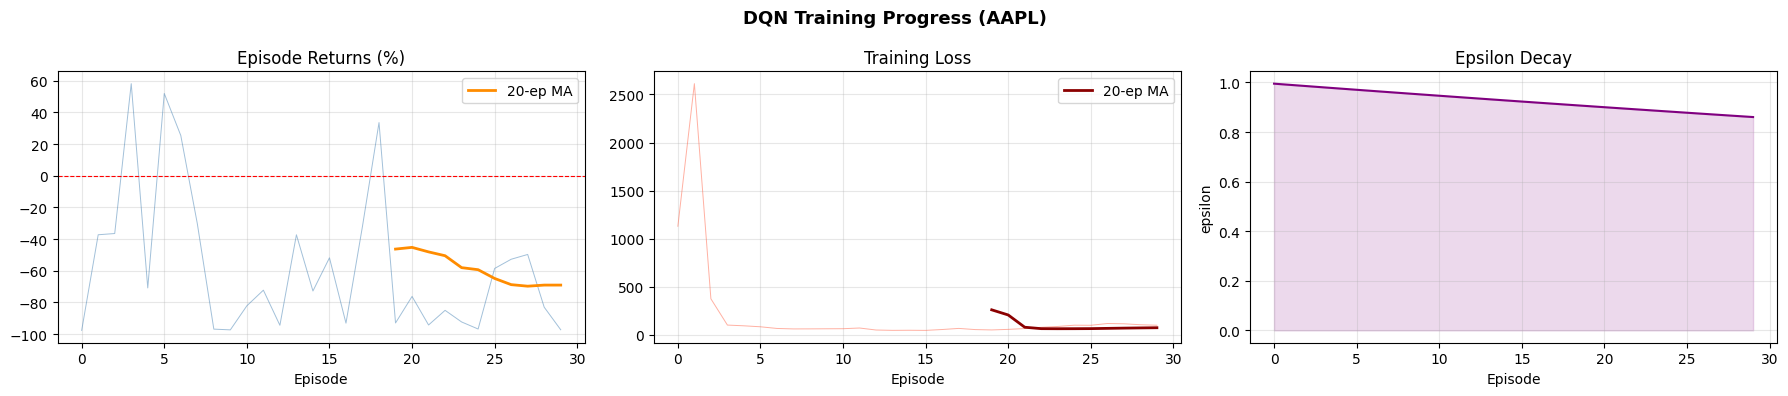

Saved: dqn_training_curves.png


In [18]:
# ─── PLOT DQN TRAINING CURVES ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('DQN Training Progress (AAPL)', fontsize=13, fontweight='bold')

axes[0].plot(dqn_episode_returns, alpha=0.5, color='steelblue', lw=0.7)
axes[0].plot(pd.Series(dqn_episode_returns).rolling(20).mean(),
             color='darkorange', lw=2, label='20-ep MA')
axes[0].axhline(0, color='red', ls='--', lw=0.8)
axes[0].set_title('Episode Returns (%)'); axes[0].set_xlabel('Episode'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(dqn_episode_losses, alpha=0.5, color='tomato', lw=0.7)
axes[1].plot(pd.Series(dqn_episode_losses).rolling(20).mean(),
             color='darkred', lw=2, label='20-ep MA')
axes[1].set_title('Training Loss'); axes[1].set_xlabel('Episode'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(dqn_epsilon_history, color='purple', lw=1.5)
axes[2].fill_between(range(len(dqn_epsilon_history)), dqn_epsilon_history, 0, alpha=0.15, color='purple')
axes[2].set_title('Epsilon Decay'); axes[2].set_xlabel('Episode'); axes[2].set_ylabel('epsilon'); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'dqn_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dqn_training_curves.png')

## 6  PPO Agent

**Proximal Policy Optimization** with Actor-Critic architecture, GAE advantage estimation, and clipped surrogate objective.

> ### 📝 TODO 7 (HARD) — Generalized Advantage Estimation
>
> Implement the backward recursion inside `compute_gae()`. GAE blends the
> 1-step TD error with longer-horizon return estimates, controlled by
> `PPO_GAE_LAMBDA`. Walk `t` backward from `T-1` down to `0` and, at each
> step, compute:
>
> - `next_val` — the value of the *next* state, but zeroed out if the episode
>   ended at step `t` (`dones[t]`). Use `last_val` when `t` is the very last
>   step of the rollout, otherwise use `values[t+1]`.
> - `delta` — the 1-step TD error: `reward[t] + gamma * next_val - values[t]`.
> - `gae` — the running advantage estimate, recursively combining `delta` with
>   the *previous* (i.e. later-in-time) `gae`, discounted by `gamma * lambda`,
>   and also zeroed across episode boundaries via `dones[t]`.
> - Store `gae` into `advantages[t]`.
>
> **Why backward?** Advantage at time `t` depends on advantage at `t+1`, so
> the recursion has to run from the end of the rollout to the start.
> `PPO_GAMMA` and `PPO_GAE_LAMBDA` are already defined constants — use them,
> don't hardcode numbers.

In [19]:
# ─── RECURRENT PPO ACTOR-CRITIC (GRUCell backbone) ────────────────────────────

class RecurrentPPOActorCritic(nn.Module):
    """
    Replaces the plain-MLP backbone with a GRUCell so the policy/value heads
    see a running summary of recent bars, not just the current one -- useful
    temporal context on top of (and complementary to) the environment's own
    frame-stacked state.

    A GRUCell (not nn.GRU) is used deliberately: it lets both single-step
    inference (rollout collection / greedy eval) and multi-step replay
    (chunked truncated-BPTT during update) share the exact same recurrence
    code, applying a done-based hidden-state reset at episode boundaries in
    both cases.
    """

    def __init__(self, state_dim, n_actions, hidden_dim=PPO_HIDDEN_DIM):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.input_proj = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh(),
        )
        self.gru_cell    = nn.GRUCell(hidden_dim, hidden_dim)
        self.policy_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, n_actions)
        )
        self.value_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )
        for layer in self.policy_head:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=0.01)
                nn.init.constant_(layer.bias, 0)

    def init_hidden(self, batch_size=1, device=DEVICE):
        return torch.zeros(batch_size, self.hidden_dim, device=device)

    def forward_step(self, x, h):
        """Single timestep: x (B, state_dim), h (B, hidden_dim) -> logits, value, new_h."""
        feat  = self.input_proj(x)
        h_new = self.gru_cell(feat, h)
        logits = self.policy_head(h_new)
        value  = self.value_head(h_new).squeeze(-1)
        return logits, value, h_new

    def get_action(self, state, hidden, mask=None):
        """Used during rollout collection: samples one action from one state/hidden."""
        logits, value, h_new = self.forward_step(state, hidden)
        if mask is not None:
            logits = logits.masked_fill(~mask, -1e9)     # invalid actions get ~zero probability
        dist   = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), value, h_new

    def evaluate_sequence(self, states_seq, h0, dones_seq, actions_seq, masks_seq):
        """
        Used during update(): replays a whole (B, T, state_dim) chunk of
        consecutive timesteps starting from the true hidden state `h0`
        recorded at that chunk's start during collection (truncated BPTT).
        Hidden state is reset to zero wherever `dones_seq` marks an episode
        boundary, exactly mirroring what collect_rollout() does.
        """
        B, T, _ = states_seq.shape
        h = h0
        logits_list, values_list = [], []
        for t in range(T):
            feat = self.input_proj(states_seq[:, t])
            h    = self.gru_cell(feat, h)
            logits_list.append(self.policy_head(h))
            values_list.append(self.value_head(h).squeeze(-1))
            not_done = (1.0 - dones_seq[:, t]).unsqueeze(-1)
            h = h * not_done                              # reset hidden after a terminal step
        logits = torch.stack(logits_list, dim=1)           # (B, T, n_actions)
        values = torch.stack(values_list, dim=1)           # (B, T)
        if masks_seq is not None:
            logits = logits.masked_fill(~masks_seq, -1e9)
        dist      = torch.distributions.Categorical(logits=logits)
        log_probs = dist.log_prob(actions_seq)
        entropy   = dist.entropy()
        return log_probs, entropy, values


# ─── PPO AGENT (recurrent, action-masked, cosine-annealed LR) ────────────────
class PPOAgent:
    def __init__(self, state_dim, n_actions, lr=None, clip_eps=None, entropy_coef=None):
        self.n_actions    = n_actions
        self.state_dim    = state_dim
        # Overridable (e.g. by Optuna) reward/optimization hyperparameters;
        # default to the module-level constants when not specified.
        self.lr            = lr           if lr           is not None else PPO_LR
        self.clip_eps       = clip_eps     if clip_eps     is not None else PPO_CLIP_EPS
        self.entropy_coef  = entropy_coef if entropy_coef is not None else PPO_ENTROPY_COEF
        self.ac        = RecurrentPPOActorCritic(state_dim, n_actions).to(DEVICE)
        self.optimizer = optim.Adam(self.ac.parameters(), lr=self.lr, eps=1e-5)
        self.scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
            self.optimizer, T_0=PPO_SCHED_T0, T_mult=2, eta_min=min(PPO_MIN_LR, self.lr))
        self.eval_hidden = None   # persistent hidden state used by select_action() for greedy eval

    def reset_hidden(self):
        """Call at the start of every fresh (greedy) evaluation episode."""
        self.eval_hidden = self.ac.init_hidden(1, DEVICE)

    def collect_rollout(self, env):
        states, actions, rewards, log_probs, values, dones, masks = [], [], [], [], [], [], []
        chunk_start_hiddens = []           # true hidden state at the start of every PPO_CHUNK_LEN block

        state  = env.reset(); done = False
        mask   = env.get_action_mask()
        hidden = self.ac.init_hidden(1, DEVICE)

        for step_i in range(PPO_ROLLOUT_STEPS):
            if step_i % PPO_CHUNK_LEN == 0:
                chunk_start_hiddens.append(hidden.detach().cpu().numpy().squeeze(0))

            s_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            m_t = torch.BoolTensor(mask).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                action, log_prob, _, value, hidden_new = self.ac.get_action(s_t, hidden, m_t)
            a_int = int(action.item())

            next_state, reward, done, _ = env.step(a_int)
            next_mask = env.get_action_mask()

            states.append(state);     actions.append(a_int)
            rewards.append(reward);   log_probs.append(float(log_prob.item()))
            values.append(float(value.item())); dones.append(float(done))
            masks.append(mask)

            hidden = hidden_new
            state, mask = next_state, next_mask
            if done:
                state  = env.reset()
                mask   = env.get_action_mask()
                hidden = self.ac.init_hidden(1, DEVICE)   # reset recurrent state at episode boundary

        with torch.no_grad():
            s_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            _, last_val, _ = self.ac.forward_step(s_t, hidden)

        return dict(states=np.array(states, dtype=np.float32),
                    actions=np.array(actions, dtype=np.int64),
                    rewards=np.array(rewards, dtype=np.float32),
                    log_probs=np.array(log_probs, dtype=np.float32),
                    values=np.array(values, dtype=np.float32),
                    dones=np.array(dones, dtype=np.float32),
                    masks=np.array(masks, dtype=bool),
                    chunk_start_hiddens=np.array(chunk_start_hiddens, dtype=np.float32),
                    last_val=float(last_val.item()))

    def compute_gae(self, rollout):
        rewards, values, dones, last_val = (
            rollout['rewards'], rollout['values'],
            rollout['dones'],   rollout['last_val']
        )
        T = len(rewards)
        advantages = np.zeros(T, dtype=np.float32)
        gae = 0.0
        # TODO 7 (HARD): implement the GAE backward recursion — see the markdown
        # cell above for the exact recursive formula. Fill `advantages[t]` for
        # every t, iterating t from T-1 down to 0.
        for t in reversed(range(T)):
            next_val = last_val if t == T - 1 else values[t + 1]
            next_val = next_val * (1 - dones[t])
            delta = rewards[t] + PPO_GAMMA * next_val - values[t]
            gae = delta + PPO_GAMMA * PPO_GAE_LAMBDA * (1 - dones[t]) * gae
            advantages[t] = gae
        
        returns    = advantages + values
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        return advantages, returns

    def update(self, rollout):
        advantages, returns = self.compute_gae(rollout)
        T          = len(rollout['states'])
        chunk_len  = PPO_CHUNK_LEN
        n_chunks   = T // chunk_len   # PPO_ROLLOUT_STEPS should be an exact multiple of PPO_CHUNK_LEN
        assert n_chunks == len(rollout['chunk_start_hiddens']), \
            'PPO_ROLLOUT_STEPS must be a multiple of PPO_CHUNK_LEN for chunk hidden-state alignment'

        states  = rollout['states'][:n_chunks*chunk_len].reshape(n_chunks, chunk_len, -1)
        actions = rollout['actions'][:n_chunks*chunk_len].reshape(n_chunks, chunk_len)
        old_lp  = rollout['log_probs'][:n_chunks*chunk_len].reshape(n_chunks, chunk_len)
        dones   = rollout['dones'][:n_chunks*chunk_len].reshape(n_chunks, chunk_len)
        masks   = rollout['masks'][:n_chunks*chunk_len].reshape(n_chunks, chunk_len, self.n_actions)
        advs    = advantages[:n_chunks*chunk_len].reshape(n_chunks, chunk_len)
        rets    = returns[:n_chunks*chunk_len].reshape(n_chunks, chunk_len)

        states_t  = torch.FloatTensor(states).to(DEVICE)
        actions_t = torch.LongTensor(actions).to(DEVICE)
        old_lp_t  = torch.FloatTensor(old_lp).to(DEVICE)
        dones_t   = torch.FloatTensor(dones).to(DEVICE)
        masks_t   = torch.BoolTensor(masks).to(DEVICE)
        advs_t    = torch.FloatTensor(advs).to(DEVICE)
        rets_t    = torch.FloatTensor(rets).to(DEVICE)
        h0_all    = torch.FloatTensor(rollout['chunk_start_hiddens']).to(DEVICE)

        chunks_per_batch = max(1, PPO_MINI_BATCH // chunk_len)   # default 1: PPO_MINI_BATCH == PPO_CHUNK_LEN
        chunk_idxs = np.arange(n_chunks)
        losses = []

        for _ in range(PPO_UPDATE_EPOCHS):
            np.random.shuffle(chunk_idxs)          # shuffle CHUNK order only, never timesteps within a chunk
            for start in range(0, n_chunks, chunks_per_batch):
                cb = chunk_idxs[start:start + chunks_per_batch]
                if len(cb) == 0:
                    continue
                h0 = h0_all[cb]
                new_lp, entropy, new_vals = self.ac.evaluate_sequence(
                    states_t[cb], h0, dones_t[cb], actions_t[cb], masks_t[cb])
                ratio  = torch.exp(new_lp - old_lp_t[cb])
                p_loss = -torch.min(ratio * advs_t[cb],
                                    torch.clamp(ratio, 1-self.clip_eps, 1+self.clip_eps) * advs_t[cb]).mean()
                v_loss = F.mse_loss(new_vals, rets_t[cb])
                loss   = p_loss + PPO_VF_COEF * v_loss - self.entropy_coef * entropy.mean()
                self.optimizer.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(self.ac.parameters(), PPO_MAX_GRAD_NORM)
                self.optimizer.step()
                losses.append(float(loss.item()))
        return np.mean(losses)

    def select_action(self, state, mask=None):
        """Greedy action for validation/evaluation. Maintains `self.eval_hidden`
        across calls -- call `reset_hidden()` once at the start of each episode."""
        if self.eval_hidden is None:
            self.reset_hidden()
        s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits, _, h_new = self.ac.forward_step(s, self.eval_hidden)
            if mask is not None:
                m = torch.BoolTensor(mask).unsqueeze(0).to(DEVICE)
                logits = logits.masked_fill(~m, -1e9)
            self.eval_hidden = h_new
        return int(torch.argmax(logits, dim=-1).item())

    def save(self, path):
        torch.save(self.ac.state_dict(), path)

    def load(self, path):
        self.ac.load_state_dict(torch.load(path, map_location=DEVICE))


print('PPO classes defined (recurrent GRU-cell actor-critic).')


PPO classes defined (recurrent GRU-cell actor-critic).


In [20]:
# ─── TRAIN PPO ────────────────────────────────────────────────────────────────
print('Training PPO Agent...')

ppo_agent     = PPOAgent(StockTradingEnv.STATE_DIM, StockTradingEnv.N_ACTIONS)
ppo_train_env = StockTradingEnv(df, start_idx=SEQUENCE_LEN, end_idx=train_end)

ppo_epoch_losses  = []
ppo_epoch_returns = []
best_ppo_val      = -np.inf
best_ppo_path     = os.path.join(REPORTS_DIR, 'ppo_best.pt')

for epoch in tqdm(range(PPO_EPOCHS), desc='PPO Training'):
    rollout = ppo_agent.collect_rollout(ppo_train_env)
    loss    = ppo_agent.update(rollout)
    ppo_agent.scheduler.step()
    ppo_epoch_losses.append(loss)

    if epoch % 10 == 0:
        val_env = StockTradingEnv(df, start_idx=train_end, end_idx=val_end)
        ppo_agent.reset_hidden()               # fresh recurrent state for a fresh episode
        sv = val_env.reset(); dv = False
        while not dv:
            mv = val_env.get_action_mask()
            av = ppo_agent.select_action(sv, mv)
            sv, _, dv, _ = val_env.step(av)
        val_ret = val_env.get_total_return_pct()
        ppo_epoch_returns.append(val_ret)
        if val_ret > best_ppo_val:
            best_ppo_val = val_ret
            ppo_agent.save(best_ppo_path)
        if epoch % 50 == 0:
            print(f'  Epoch {epoch:3d} | Val: {val_ret:+7.2f}% | Loss: {loss:.6f}')

ppo_agent.load(best_ppo_path)
print(f'PPO Training done. Best val return: {best_ppo_val:.2f}%')

Training PPO Agent...


PPO Training:   0%|          | 0/20 [00:00<?, ?it/s]

  Epoch   0 | Val:  -49.46% | Loss: 1902587.528153
PPO Training done. Best val return: -49.46%


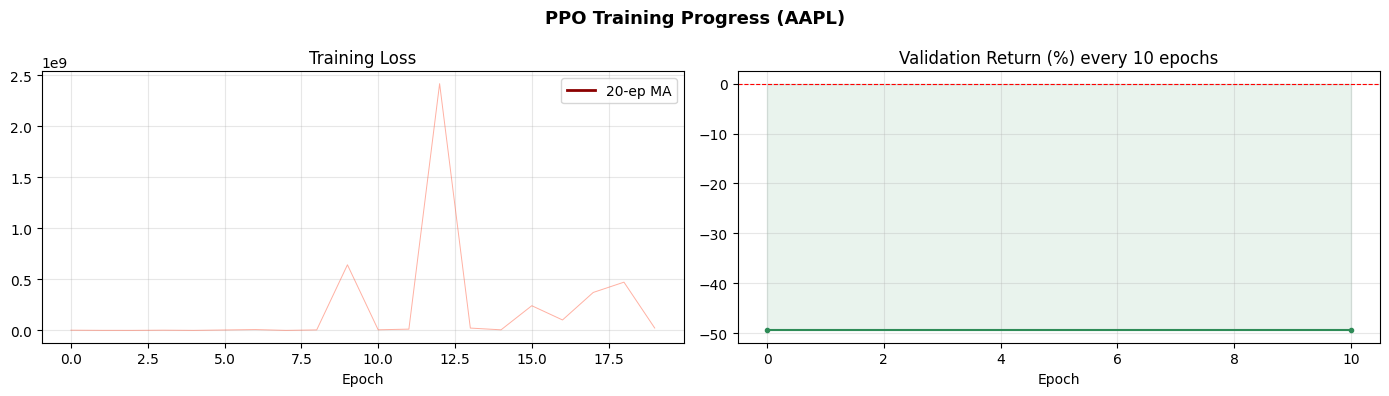

Saved: ppo_training_curves.png


In [21]:
# ─── PLOT PPO TRAINING CURVES ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('PPO Training Progress (AAPL)', fontsize=13, fontweight='bold')

axes[0].plot(ppo_epoch_losses, alpha=0.5, color='tomato', lw=0.7)
axes[0].plot(pd.Series(ppo_epoch_losses).rolling(20).mean(), color='darkred', lw=2, label='20-ep MA')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

ep_x = list(range(0, PPO_EPOCHS, 10))
axes[1].plot(ep_x, ppo_epoch_returns, color='seagreen', lw=1.5, marker='o', ms=3)
axes[1].fill_between(ep_x, ppo_epoch_returns, 0, alpha=0.1, color='seagreen')
axes[1].axhline(0, color='red', ls='--', lw=0.8)
axes[1].set_title('Validation Return (%) every 10 epochs'); axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'ppo_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ppo_training_curves.png')

## 7  Evaluate on Test Set

In [22]:
# ─── EVALUATION HELPER ───────────────────────────────────────────────────────
def run_episode(agent, env):
    """Run one full episode (greedy) and compute all metrics."""
    state = env.reset(); done = False
    if not isinstance(agent, DQNAgent):
        agent.reset_hidden()          # fresh recurrent state for the PPO agent at episode start
    while not done:
        mask = env.get_action_mask()
        if isinstance(agent, DQNAgent):
            action = agent.select_action(state, mask, training=False)
        else:
            action = agent.select_action(state, mask)
        state, _, done, _ = env.step(action)

    pvh = np.array(env.portfolio_value_history)
    dr  = np.diff(pvh) / pvh[:-1]

    total_ret = (pvh[-1] / pvh[0] - 1) * 100
    ann_ret   = ((pvh[-1] / pvh[0]) ** (252 / max(len(pvh), 1)) - 1) * 100
    sharpe    = (dr.mean() / (dr.std() + 1e-8)) * np.sqrt(252) if len(dr) > 0 else 0.0
    peak = np.maximum.accumulate(pvh)
    mdd  = float(((pvh - peak) / peak).min() * 100)

    trades = env.trade_history
    pnls   = []
    buy_px = None
    for t in trades:
        if t['action'] == 'BUY':
            buy_px = t['price']
        elif t['action'] == 'SELL' and buy_px is not None:
            pnls.append(t['price'] - buy_px)
            buy_px = None
    win_rate = (np.array(pnls) > 0).mean() * 100 if pnls else 0.0

    return dict(total_return=total_ret, ann_return=ann_ret, sharpe=sharpe,
                max_drawdown=mdd, win_rate=win_rate, n_trades=len(pnls),
                portfolio_values=pvh, daily_returns=dr,
                trade_history=trades,
                dates=env.df.iloc[env.start_idx:env.end_idx]['date'].values)

In [23]:
# ─── TEST EVALUATION ─────────────────────────────────────────────────────────
dqn_test_env = StockTradingEnv(df, start_idx=val_end, end_idx=N-1)
dqn_results  = run_episode(dqn_agent, dqn_test_env)

ppo_test_env = StockTradingEnv(df, start_idx=val_end, end_idx=N-1)
ppo_results  = run_episode(ppo_agent, ppo_test_env)

print('=== Test Set Results ===')
print(f'{"Metric":<18} {"DQN":>12} {"PPO":>12}')
print('-' * 44)
for key, label in [('total_return','Total Return %'), ('ann_return','Ann. Return %'),
                   ('sharpe','Sharpe Ratio'), ('max_drawdown','Max Drawdown %'),
                   ('win_rate','Win Rate %'), ('n_trades','# Trades')]:
    dv = dqn_results[key]
    pv = ppo_results[key]
    if isinstance(dv, float):
        print(f'{label:<18} {dv:>+12.2f} {pv:>+12.2f}')
    else:
        print(f'{label:<18} {dv:>12} {pv:>12}')

=== Test Set Results ===
Metric                      DQN          PPO
--------------------------------------------
Total Return %            +0.00        +9.76
Ann. Return %             +0.00        +1.85
Sharpe Ratio              +0.00        +0.21
Max Drawdown %            +0.00       -21.73
Win Rate %                +0.00       +55.90
# Trades                      0          322


## 8  Save Results

In [24]:
# ─── SAVE RL RESULTS ─────────────────────────────────────────────────────────
rl_results = {
    'DQN': dqn_results,
    'PPO': ppo_results,
    'test_start_idx': val_end,
    'test_end_idx':   N - 1,
    'test_dates':     df.iloc[val_end:N-1]['date'].values,
    'test_prices':    df.iloc[val_end:N-1]['close'].values,
    'dqn_episode_returns': dqn_episode_returns,
    'dqn_episode_losses':  dqn_episode_losses,
    'dqn_epsilon_history': dqn_epsilon_history,
    'ppo_epoch_losses':    ppo_epoch_losses,
    'ppo_epoch_returns':   ppo_epoch_returns,
    'hyperparams': {
        'DQN': dict(episodes=DQN_EPISODES, gamma=DQN_GAMMA, lr=DQN_LR,
                    eps_start=DQN_EPS_START, eps_end=DQN_EPS_END,
                    eps_decay=DQN_EPS_DECAY, batch_size=DQN_BATCH_SIZE,
                    memory=DQN_MEMORY_SIZE, hidden=DQN_HIDDEN_DIM,
                    target_update=DQN_TARGET_UPDATE),
        'PPO': dict(epochs=PPO_EPOCHS, rollout_steps=PPO_ROLLOUT_STEPS,
                    mini_batch=PPO_MINI_BATCH, lr=PPO_LR,
                    gamma=PPO_GAMMA, gae_lambda=PPO_GAE_LAMBDA,
                    clip_eps=PPO_CLIP_EPS, entropy_coef=PPO_ENTROPY_COEF,
                    vf_coef=PPO_VF_COEF, update_epochs=PPO_UPDATE_EPOCHS,
                    hidden=PPO_HIDDEN_DIM)
    }
}

save_path = os.path.join(REPORTS_DIR, 'rl_results.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(rl_results, f)
print(f'Saved: {save_path}')

# CSV summary
summary = pd.DataFrame({
    'Agent': ['DQN', 'PPO'],
    'Total Return (%)':  [dqn_results['total_return'],  ppo_results['total_return']],
    'Ann. Return (%)':   [dqn_results['ann_return'],    ppo_results['ann_return']],
    'Sharpe Ratio':      [dqn_results['sharpe'],        ppo_results['sharpe']],
    'Max Drawdown (%)':  [dqn_results['max_drawdown'],  ppo_results['max_drawdown']],
    'Win Rate (%)':      [dqn_results['win_rate'],      ppo_results['win_rate']],
    '# Trades':          [dqn_results['n_trades'],      ppo_results['n_trades']],
})
summary.to_csv(os.path.join(REPORTS_DIR, 'rl_agent_summary.csv'), index=False)
print('Saved: rl_agent_summary.csv')
print()
print(summary.to_string(index=False))

Saved: /Users/azimahmed/Desktop/Github:stock/SOC-Stock-Trading-With-LSTM-And-RL/Week6/reports/rl_results.pkl
Saved: rl_agent_summary.csv

Agent  Total Return (%)  Ann. Return (%)  Sharpe Ratio  Max Drawdown (%)  Win Rate (%)  # Trades
  DQN          0.000000         0.000000       0.00000          0.000000      0.000000         0
  PPO          9.757664         1.846989       0.20688        -21.729938     55.900621       322


## 9  Hyperparameter Optimization (Optuna)

Searches for reward-shaping and optimization hyperparameters that maximize a
**custom risk-adjusted objective** on the validation split (never the test
split, to avoid leaking test-set information into model selection):

$$\text{Objective} = \text{Total Return \%} - 2 \cdot |\text{Max Drawdown \%}| - (\text{\#Trades} \times 0.05)$$

This directly rewards profitable agents that (a) avoid deep drawdowns (2x
penalty weight) and (b) don't overtrade (flat 0.05 penalty per trade,
independent of the environment's own overtrading reward term -- this is a
*selection* criterion on top of, not a replacement for, the reward function
the agent is actually trained with).

Each trial trains a **fresh** agent for a reduced number of
episodes/epochs (`OPTUNA_DQN_EPISODES` / `OPTUNA_PPO_EPOCHS`, both far
shorter than the full `DQN_EPISODES` / `PPO_EPOCHS` used above) -- standard
practice for HPO: search cheaply, then retrain the winning configuration at
full budget. A `MedianPruner` stops clearly-underperforming trials early
using periodic validation checkpoints, saving compute.

**Search space:**

| Hyperparameter | Distribution | Range | Applies to |
|---|---|---|---|
| `lr` | log-uniform | `[1e-5, 1e-3]` | DQN & PPO |
| `dd_penalty_coef` | uniform | `[0.005, 0.15]` | DQN & PPO (env reward) |
| `txn_penalty_coef` | log-uniform | `[3e-4, 1e-2]` | DQN & PPO (env reward) |
| `clip_eps` | uniform | `[0.1, 0.3]` | PPO only |
| `entropy_coef` | log-uniform | `[1e-3, 1e-1]` | PPO only |

`dd_penalty_coef`'s default in the main pipeline is `0.02` and
`txn_penalty_coef`'s default is `0.0015` (see Constants cell) -- both search
ranges are centered around those defaults, wide enough to let Optuna find a
meaningfully different value but not so wide that the reward becomes
numerically unstable. `txn_penalty_coef` and `entropy_coef` use log-uniform
sampling since a sensible value could plausibly sit anywhere across roughly
two orders of magnitude.

In [25]:
# ─── OPTUNA SETUP ──────────────────────────────────────────────────────────
import json
try:
    import optuna
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Search-budget hyperparameters (deliberately smaller than full training) ──
OPTUNA_N_TRIALS_DQN   = 3
OPTUNA_N_TRIALS_PPO   = 3
OPTUNA_DQN_EPISODES   = 40     # vs. DQN_EPISODES = 300 in full training
OPTUNA_PPO_EPOCHS     = 25     # vs. PPO_EPOCHS   = 200 in full training
OPTUNA_EVAL_EVERY_DQN = 10     # episodes between pruning checkpoints
OPTUNA_EVAL_EVERY_PPO = 5      # epochs between pruning checkpoints


def custom_objective(metrics):
    """Objective = Total Return% - 2*|Max Drawdown%| - (#Trades * 0.05).
    Heavily penalizes drawdown and discourages overtrading beyond what the
    environment's own reward function already discourages."""
    return (metrics['total_return']
            - 2.0 * abs(metrics['max_drawdown'])
            - metrics['n_trades'] * 0.05)


print('Optuna ready. custom_objective(metrics) = Total Return% - 2*|MaxDD%| - #Trades*0.05')


Optuna ready. custom_objective(metrics) = Total Return% - 2*|MaxDD%| - #Trades*0.05


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [27]:
# ─── DQN OPTUNA OBJECTIVE ─────────────────────────────────────────────────

def dqn_objective(trial):
    lr        = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    dd_coef   = trial.suggest_float('dd_penalty_coef', 0.005, 0.15)
    txn_coef  = trial.suggest_float('txn_penalty_coef', 3e-4, 1e-2, log=True)

    agent = DQNAgent(StockTradingEnv.STATE_DIM, StockTradingEnv.N_ACTIONS, lr=lr)
    train_env = StockTradingEnv(df, start_idx=SEQUENCE_LEN, end_idx=train_end,
                                 dd_penalty_coef=dd_coef, txn_penalty_coef=txn_coef)
    env_kwargs = dict(dd_penalty_coef=dd_coef, txn_penalty_coef=txn_coef)

    for episode in range(OPTUNA_DQN_EPISODES):
        state = train_env.reset(); mask = train_env.get_action_mask(); done = False
        while not done:
            action = agent.select_action(state, mask, training=True)
            next_state, reward, done, _ = train_env.step(action)
            next_mask = train_env.get_action_mask()
            agent.store(state, action, reward, next_state, float(done), mask, next_mask)
            agent.update()
            state, mask = next_state, next_mask

        agent.decay_epsilon()
        agent.scheduler.step()
        if episode % DQN_TARGET_UPDATE == 0:
            agent.sync_target()

        # Periodic validation checkpoint -> lets the pruner kill bad trials early
        if episode % OPTUNA_EVAL_EVERY_DQN == 0 or episode == OPTUNA_DQN_EPISODES - 1:
            val_env = StockTradingEnv(df, start_idx=train_end, end_idx=val_end, **env_kwargs)
            metrics = run_episode(agent, val_env)
            score   = custom_objective(metrics)
            trial.report(score, step=episode)
            if trial.should_prune():
                raise optuna.TrialPruned()

    val_env = StockTradingEnv(df, start_idx=train_end, end_idx=val_end, **env_kwargs)
    metrics = run_episode(agent, val_env)
    score   = custom_objective(metrics)

    trial.set_user_attr('total_return', metrics['total_return'])
    trial.set_user_attr('max_drawdown', metrics['max_drawdown'])
    trial.set_user_attr('sharpe', metrics['sharpe'])
    trial.set_user_attr('n_trades', metrics['n_trades'])
    return score


print('dqn_objective defined.')


dqn_objective defined.


In [33]:
# ─── PPO OPTUNA OBJECTIVE ─────────────────────────────────────────────────

def ppo_objective(trial):
    lr           = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    dd_coef      = trial.suggest_float('dd_penalty_coef', 0.005, 0.15)
    txn_coef     = trial.suggest_float('txn_penalty_coef', 3e-4, 1e-2, log=True)
    clip_eps     = trial.suggest_float('clip_eps', 0.1, 0.3)
    entropy_coef = trial.suggest_float('entropy_coef', 1e-3, 1e-1, log=True)

    agent = PPOAgent(StockTradingEnv.STATE_DIM, StockTradingEnv.N_ACTIONS,
                      lr=lr, clip_eps=clip_eps, entropy_coef=entropy_coef)
    train_env = StockTradingEnv(df, start_idx=SEQUENCE_LEN, end_idx=train_end,
                                 dd_penalty_coef=dd_coef, txn_penalty_coef=txn_coef)
    env_kwargs = dict(dd_penalty_coef=dd_coef, txn_penalty_coef=txn_coef)

    for epoch in range(OPTUNA_PPO_EPOCHS):
        rollout = agent.collect_rollout(train_env)
        agent.update(rollout)
        agent.scheduler.step()

        if epoch % OPTUNA_EVAL_EVERY_PPO == 0 or epoch == OPTUNA_PPO_EPOCHS - 1:
            val_env = StockTradingEnv(df, start_idx=train_end, end_idx=val_end, **env_kwargs)
            agent.reset_hidden()
            metrics = run_episode(agent, val_env)
            score   = custom_objective(metrics)
            trial.report(score, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    val_env = StockTradingEnv(df, start_idx=train_end, end_idx=val_end, **env_kwargs)
    agent.reset_hidden()
    metrics = run_episode(agent, val_env)
    score   = custom_objective(metrics)

    trial.set_user_attr('total_return', metrics['total_return'])
    trial.set_user_attr('max_drawdown', metrics['max_drawdown'])
    trial.set_user_attr('sharpe', metrics['sharpe'])
    trial.set_user_attr('n_trades', metrics['n_trades'])
    return score


print('ppo_objective defined.')


ppo_objective defined.
